# Working hours

Average weekly hours actually worked per employed person, from the **ILO Modelled Estimates (ILOEST)** database — the imputed/nowcast series that covers ~190 countries annually, as opposed to the raw COND survey series (`HOW_TEMP_SEX_NB_A`) which has large per-country gaps. Lower hours is better for livability (more leisure, better work-life balance), so we sign-invert to the atlas convention (higher = better). 🔴 **Tier C** in `DATASETS.md`: country-level by construction, flat inside each border.

## Why the modelled series

The COND raw survey series (`HOW_TEMP_SEX_NB_A`) reports whatever the national statistical office publishes — for many countries that means an old year, or nothing at all. The ILOEST modelled series (`HOW_2EMP_SEX_NB_A`) fills the gaps with model-based nowcasts anchored to the surveys the ILO does have, plus population/demographic covariates from UN WPP. Trade-off: within the ILO's coverage universe both agree closely; the ILOEST version just has ~190 countries every year instead of a patchy ~90.

## Why not richer breakdowns

* **OECD Better Life Index "Work-Life Balance"** — richer (long-hours-% + leisure-time), but ~40 OECD/partner countries only. Would sharpen the corner of the map already best-served and require a blend layer with a real methodology choice; deferred until we have a use case for it.
* **COND `HOW_EES_SEX_ECO_NB_A` "% employees working >48h/week"** — a tail-risk measure of overwork culture; potentially a good second layer next to average hours but adds another metric rather than sharpening this one. Not implemented.

## Indicator discovery

ILOSTAT occasionally re-codes indicators between catalogue updates (the November modelled-estimates release bumps some ids). Rather than hardcoding a string that may go stale, we hit the [rplumber TOC endpoint](https://rplumber.ilo.org/metadata/toc/indicator?lang=en&format=.csv) and look up whichever annual ILOEST indicator currently carries the label "Average weekly hours actually worked per employed person" — that lookup returns `HOW_2EMP_SEX_NB_A` today and will follow along if it shifts. If ILOSTAT ever drops the label pattern we fall back to that hardcoded id and log a warning.

In [1]:
import pandas as pd
import xarray as xr

from common import RAW_DIR, download, load_country_mask, load_grid, plot_map, save_variable

VARIABLE = 'working_hours'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Discover the current ILOEST hours indicator

The rplumber TOC lists every indicator with its database and label. We keep the annual (`freq == 'A'`) ILOEST rows whose label matches "Average weekly hours actually worked per employed person" *and* whose classification is just `SEX` (no age/economic-activity breakdown), which uniquely selects `HOW_2EMP_SEX_NB_A` — the total-hours modelled series with the widest country coverage. The TOC is ~700 KB, cached locally so re-runs are offline.

In [2]:
TOC_URL = 'https://rplumber.ilo.org/metadata/toc/indicator?lang=en&format=.csv'
toc_path = variable_raw / 'ilostat_toc.csv'

if not toc_path.exists():
    await download(TOC_URL, toc_path)

toc = pd.read_csv(toc_path)
candidates = toc[
    (toc['database'] == 'ILOEST')
    & (toc['freq'] == 'A')
    & toc['rep_var.label'].str.contains('Average weekly hours actually worked per employed person', case=False, na=False)
    & (toc['classification'] == 'SEX')
]
print(f'{len(candidates)} candidate indicator(s):')
print(candidates[['id', 'indicator.label', 'data.start', 'data.end', 'n.ref_area']].to_string(index=False))

INDICATOR = candidates['id'].iloc[0] if len(candidates) else 'HOW_2EMP_SEX_NB_A'
if not len(candidates):
    print(f'!! no ILOEST match in TOC — falling back to hardcoded {INDICATOR}')
print(f'using indicator: {INDICATOR}')

https://rplumber.ilo.org/metadata/toc/indicator?lang=en&format=.csv: 0.00B [00:00, ?B/s]

https://rplumber.ilo.org/metadata/toc/indicator?lang=en&format=.csv: 63.1kB [00:00, 1.66MB/s]

1 candidate indicator(s):
               id                                                                                      indicator.label  data.start  data.end  n.ref_area
HOW_2EMP_SEX_NB_A Average weekly hours actually worked per employed person by sex -- ILO modelled estimates, Nov. 2025        2005      2027         276
using indicator: HOW_2EMP_SEX_NB_A


## 2. Fetch the indicator data

One CSV per indicator, ~1 MB — the annual modelled series covers 2005 through the current model horizon (2027 in the November 2025 release, three years of nowcast on top of the historical fit). Cached locally, so re-runs skip the download.

In [3]:
data_url = f'https://rplumber.ilo.org/data/indicator/?id={INDICATOR}&format=.csv'
data_path = variable_raw / f'{INDICATOR}.csv'

if not data_path.exists():
    await download(data_url, data_path)

print(f'{data_path.name}: {data_path.stat().st_size / 1024:.0f} KB')

https://rplumber.ilo.org/data/indicator/?id=HOW_2EMP_SEX_NB_A&format=.csv: 0.00B [00:00, ?B/s]

https://rplumber.ilo.org/data/indicator/?id=HOW_2EMP_SEX_NB_A&format=.csv: 101kB [00:00, 1.44MB/s]

HOW_2EMP_SEX_NB_A.csv: 1049 KB


## 3. Latest total-sex hours per country

Keep `SEX_T` (both sexes) rows, take the latest year per `ref_area`. The ILO already uses standard ISO3 in `ref_area` for countries, so no name-alias table is needed — regional aggregates (`X01`..`X99`, `WLD`, ...) do not match any Natural Earth ISO3 and drop out silently on the join in the next cell. We include nowcast years (2026–2027) because the modelled series is designed to be used through its horizon; if you want observed-only, cap `time` at the current year.

In [4]:
raw = pd.read_csv(data_path)
print(f'{len(raw):,} rows, columns: {list(raw.columns)}')

total = raw[raw['sex'] == 'SEX_T'].dropna(subset=['obs_value'])
latest = (
    total.sort_values('time')
         .groupby('ref_area', as_index=False)
         .tail(1)
         .set_index('ref_area')
         .rename(columns={'obs_value': 'hours', 'time': 'year'})
         [['year', 'hours']]
)
print(f'{len(latest)} ref_areas (countries + regional aggregates) '
      f'with hours (years {int(latest["year"].min())}–{int(latest["year"].max())}, '
      f'range [{latest["hours"].min():.1f}, {latest["hours"].max():.1f}])')
latest.head()

18,972 rows, columns: ['ref_area', 'source', 'indicator', 'sex', 'time', 'obs_value', 'obs_status']
276 ref_areas (countries + regional aggregates) with hours (years 2021–2027, range [23.4, 54.7])


,year,hours
ref_area,,
UKR,2021,39.11
SDN,2022,50.76
PSE,2022,39.68
SSD,2023,37.60
LBN,2023,46.77


## 4. Rasterise onto the atlas grid

Standard country-mask join, same pattern as `34_human_freedom` / `35_corruption` / `37_people_happiness`: `load_country_mask` returns an ISO3 string per grid cell, we map each cell to its country's `hours`, reshape onto `(lat, lon)`. Then **sign-invert** — the atlas convention is higher = better, but longer hours worked is worse for work-life balance, so we negate. Ocean is masked via `is_land` from `grid.nc`.

In [5]:
grid = load_grid()
iso_per_cell = load_country_mask()

raster = (
    pd.Series(iso_per_cell.values.ravel())
      .map(latest['hours'])
      .to_numpy(dtype='float32')
      .reshape(iso_per_cell.shape)
)

# Longer hours = worse work-life balance; invert so higher = better, then mask ocean.
values = (
    xr.DataArray(-raster, coords=iso_per_cell.coords, dims=iso_per_cell.dims, name=VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['source'] = (
    f'ILOSTAT {INDICATOR} (ILO Modelled Estimates), '
    f'latest year per country up to {int(latest["year"].max())}'
)
values.attrs['units'] = 'negated weekly hours (higher = fewer hours worked = better)'
values.attrs['orientation'] = 'sign-inverted so higher = better (atlas convention)'

land_cells = int((grid.is_land == 1).sum())
covered = int(values.notnull().sum())
print(f'{covered}/{land_cells} land cells covered ({100 * covered / land_cells:.1f}%)')
print(f'raw hours range: {float(latest["hours"].min()):.1f} .. {float(latest["hours"].max()):.1f}')
print(f'stored values range: {float(values.min()):.2f} .. {float(values.max()):.2f}')

64430/68294 land cells covered (94.3%)
raw hours range: 23.4 .. 54.7
stored values range: -54.67 .. -23.37


## 5. Plot

<Axes: title={'center': 'Working hours (ILOEST, negated → higher = better)'}, xlabel='longitude', ylabel='latitude'>

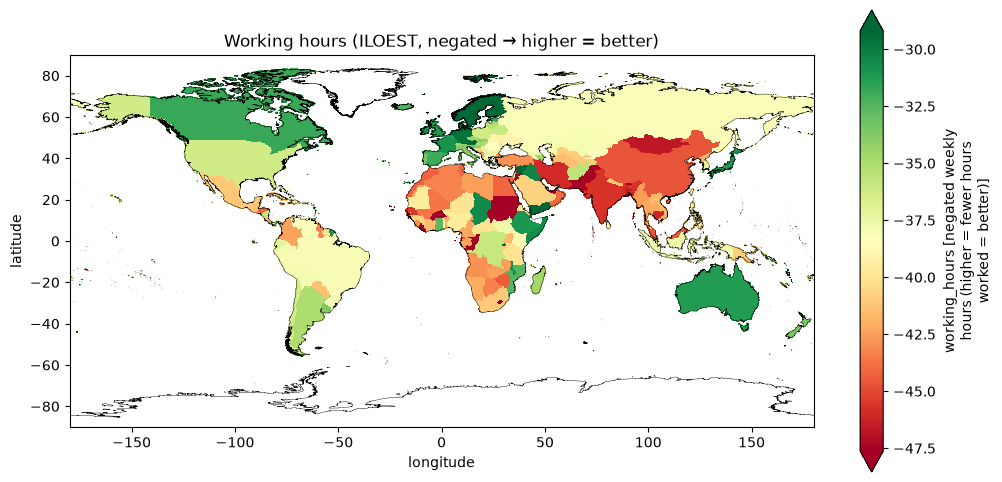

In [6]:
plot_map(values, cmap='RdYlGn', robust=True, title='Working hours (ILOEST, negated → higher = better)')

## 6. Save

In [7]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/working_hours.nc
